In [2]:
from contextlib import suppress
from nanover.recording import NanoverRecordingReader
from nanover.trajectory import MissingDataError

def read_recording(path):
    health_key = None
    data = []

    with NanoverRecordingReader.from_path(path) as reader:
        for entry, change in reader.iter_state_updates():
            for key in change.updates:
                if "report.connection.health" in key:
                    health_key = key

        for event in reader.iter_max():
            if event.next_state_event is not None:
                with suppress(MissingDataError):
                    data.append({ "particles": event.next_frame.particle_count, "timestamp": event.timestamp, **event.next_state.get(health_key) })

    print(len(data), "x", health_key)
    return data

In [3]:
SOLVENT_HIDDEN_1_USER_0_DUMMY_APK = read_recording("solvent-hidden-1-user.nanover.zip")
SOLVENT_HIDDEN_1_USER_1_DUMMY_APK = read_recording("solvent-hidden-1-user-1-dummy.nanover.zip")
SOLVENT_HIDDEN_1_USER_2_DUMMY_APK = read_recording("solvent-hidden-1-user-2-dummy.nanover.zip")
SOLVENT_HIDDEN_1_USER_3_DUMMY_APK = read_recording("solvent-hidden-1-user-3-dummy.nanover.zip")
SOLVENT_HIDDEN_1_USER_3_DUMMY_APK_GRANULAR = read_recording("solvent-hidden-1-user-3-dummy--granular.nanover.zip")

SOLVENT_VISIBLE_1_USER_APK_FPS_GRANULAR = read_recording("solvent-visible-1-user--granular--fps.nanover.zip")
SOLVENT_VISIBLE_1_USER_APK_FPS = read_recording("solvent-visible-1-user--fps.nanover.zip")
SOLVENT_VISIBLE_1_USER_PC_FPS_GRANULAR = read_recording("solvent-visible-1-user--fps--PC-VR.nanover.zip")


1700 x report.connection.health.c260c45b-4125-47cf-ae2c-6c53586b9580
2013 x report.connection.health.d6e69468-a7f0-46ee-b6f1-72c7863c09ac
1637 x report.connection.health.bdb2ed20-7a8c-441c-bd1a-7efeccfd4d79
1712 x report.connection.health.f18daffc-69e1-46d4-8391-1ed245806065
1818 x report.connection.health.da661468-b40d-418d-b830-3e1143c09882
1468 x report.connection.health.01860738-dd1c-4691-9ba6-0dbfec30119f
1255 x report.connection.health.17802d6f-8080-490b-937c-aca89d34e9a2
1301 x report.connection.health.303cf618-7e6c-4ba8-93d2-69d69272052b


(0.0, 35.0)

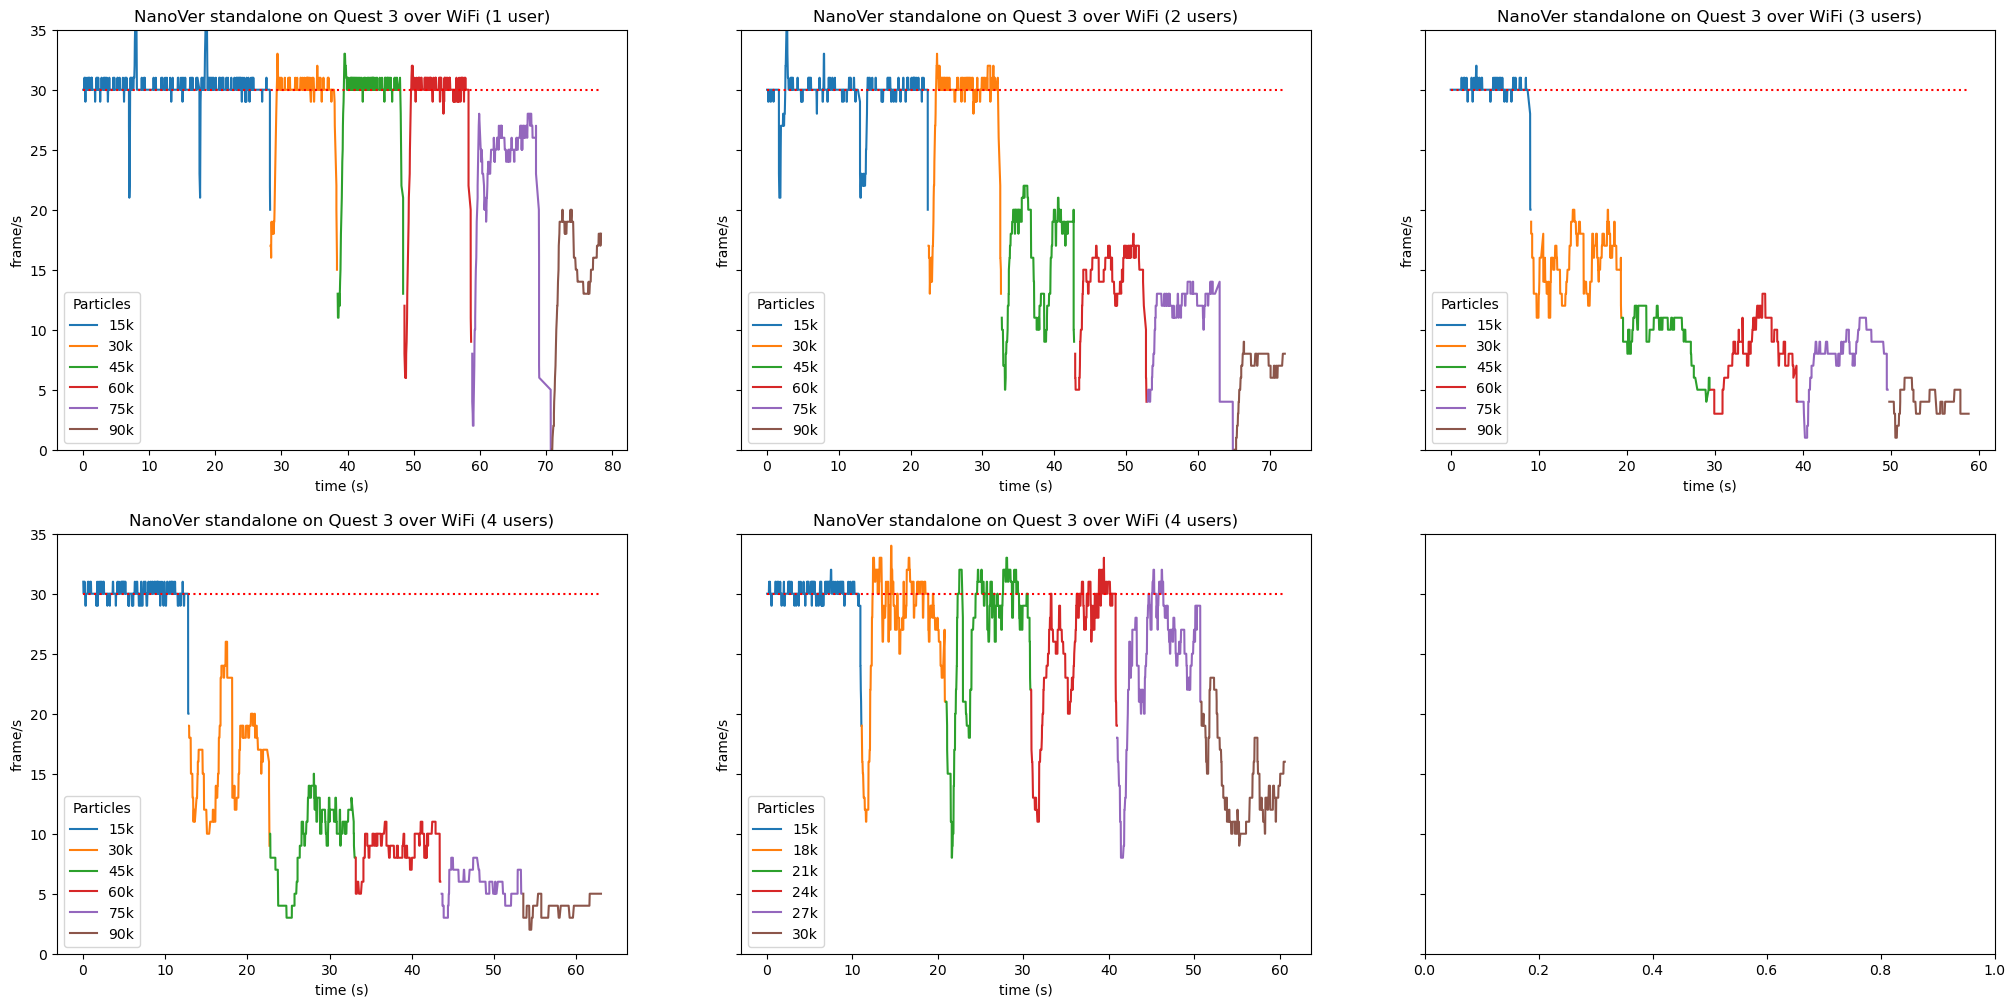

In [4]:
import matplotlib.pyplot as plt
import numpy as np

f, axes = plt.subplots(2, 3, sharey=True)
f.set_figwidth(25)
f.set_figheight(12)

DATASETS = [
    (SOLVENT_HIDDEN_1_USER_0_DUMMY_APK, "1 user"),
    (SOLVENT_HIDDEN_1_USER_1_DUMMY_APK, "2 users"),
    (SOLVENT_HIDDEN_1_USER_2_DUMMY_APK, "3 users"),
    (SOLVENT_HIDDEN_1_USER_3_DUMMY_APK, "4 users"),
    (SOLVENT_HIDDEN_1_USER_3_DUMMY_APK_GRANULAR, "4 users"),
]

for i, (DATASET, LABEL) in enumerate(DATASETS):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("frame/s")

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["frame"]] for line in DATASET if line["particles"] == count]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [pair[1] for pair in DATA]
        ax.plot(DATA_X, DATA_Y, label=f"{count//1000}k")

    ax.legend(title="Particles", loc="lower left")
    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    ax.hlines(30, 0, max(DATA_X), color="red", linestyles="dotted")
    ax.legend(title="Particles", loc="lower left")

plt.ylim(top=35, bottom=0)
# plt.ylim(top=250)

In [5]:
DATASETS_REDO = [
    (read_recording("REDO--solvent-hidden-1-user.nanover.zip"), "1 user"),
    (read_recording("REDO--solvent-hidden-2-user.nanover.zip"), "2 user"),
    (read_recording("REDO--solvent-hidden-3-user.nanover.zip"), "3 user"),
    (read_recording("REDO--solvent-hidden-4-user.nanover.zip"), "4 user"),
    (read_recording("REDO--solvent-hidden-4-user--granular.nanover.zip"), "4 user"),
]

3960 x report.connection.health.3d3ffe60-6eef-4689-a344-26cfd88a7432
5178 x report.connection.health.186d8ab0-a56c-4fb5-ad43-b95c303d8638
5185 x report.connection.health.b343fdff-ef21-4506-b9cb-9138a7b74e14
4652 x report.connection.health.6dabc38a-eefd-49fd-995c-244c2bc198bb
5405 x report.connection.health.73949135-b8da-4b5d-a1b5-35327c8049b5


(0.0, 35.0)

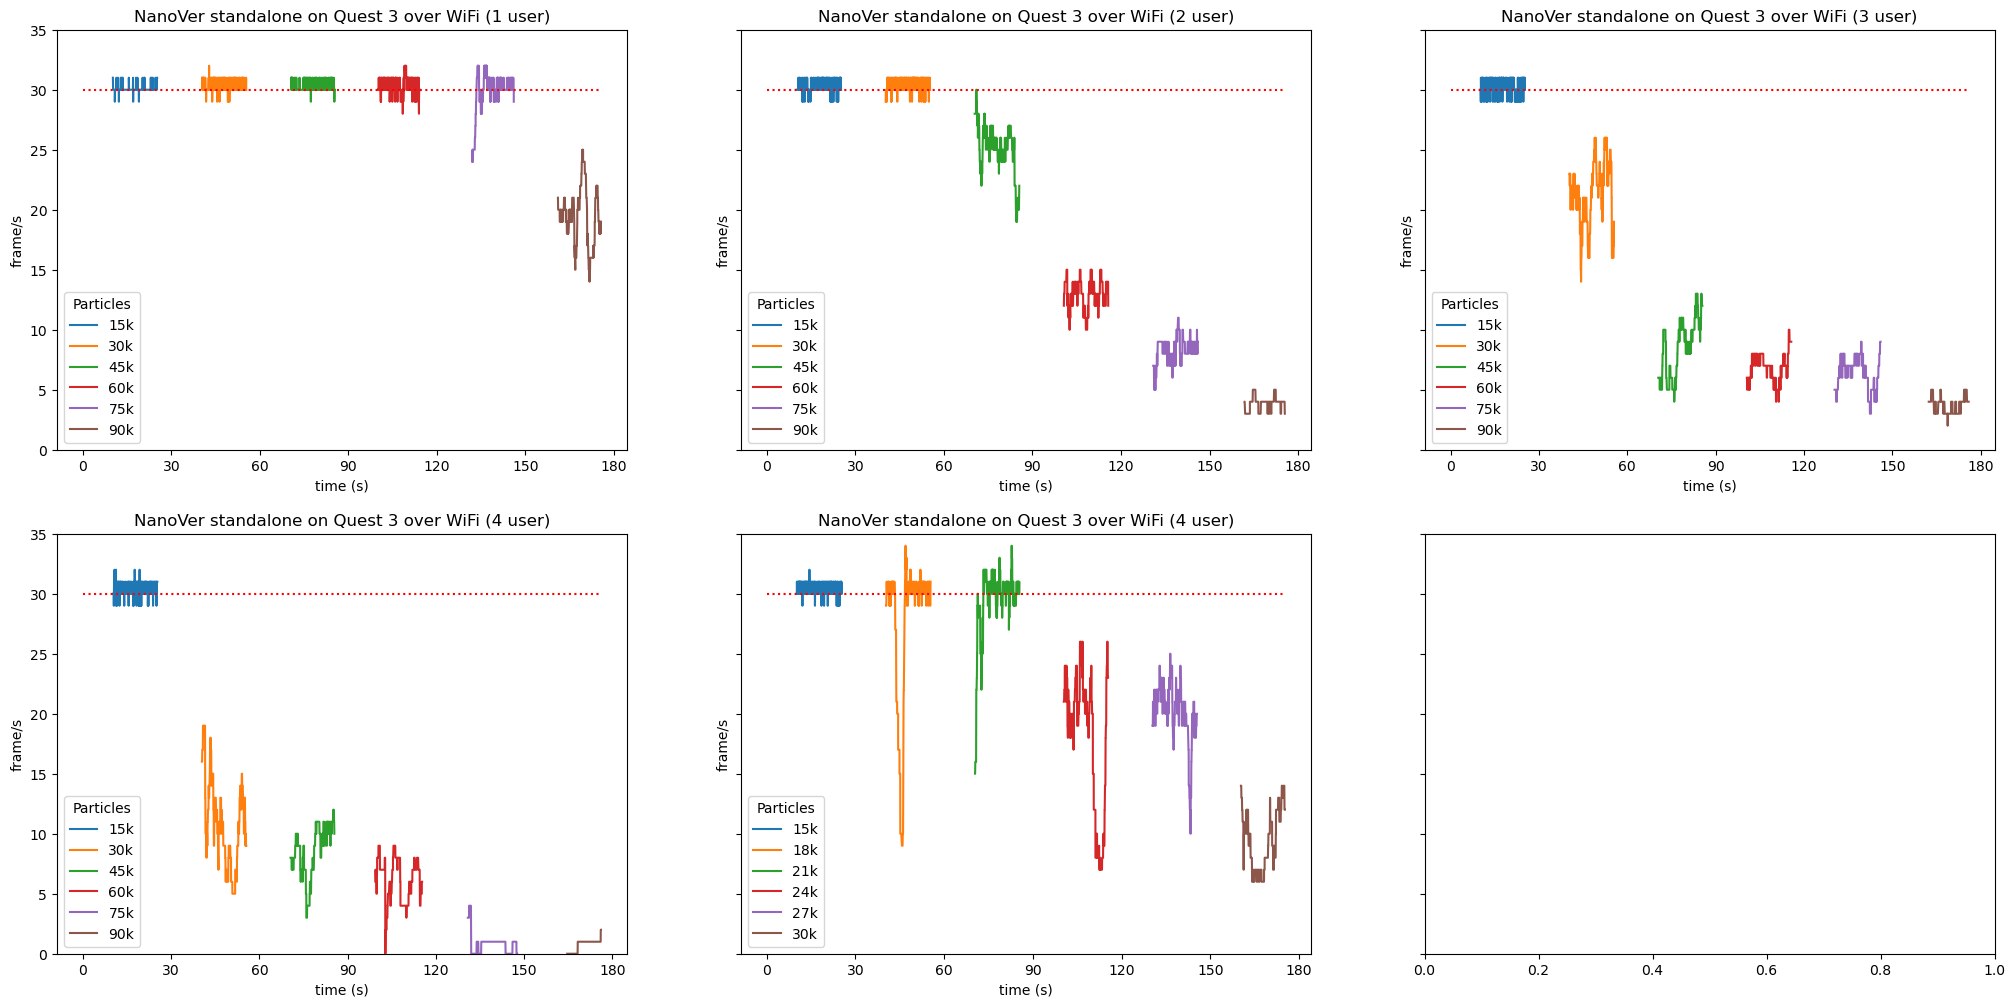

In [6]:
import matplotlib.pyplot as plt
import numpy as np

f, axes = plt.subplots(2, 3, sharey=True)
f.set_figwidth(25)
f.set_figheight(12)

for i, (DATASET, LABEL) in enumerate(DATASETS_REDO):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("frame/s")

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["frame"]] for line in DATASET if line["particles"] == count]
        third = len(DATA) // 3
        sixth = len(DATA) // 6
        DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        ax.plot(DATA_X, DATA_Y, label=f"{count//1000}k")

    ax.legend(title="Particles", loc="lower left")
    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    ax.hlines(30, 0, max(DATA_X), color="red", linestyles="dotted")
    ax.set_xticks([x*30 for x in range(len(DATASETS)+2)])
    ax.legend(title="Particles", loc="lower left")

plt.ylim(top=35, bottom=0)
# plt.ylim(top=250)

(0.0, 2000.0)

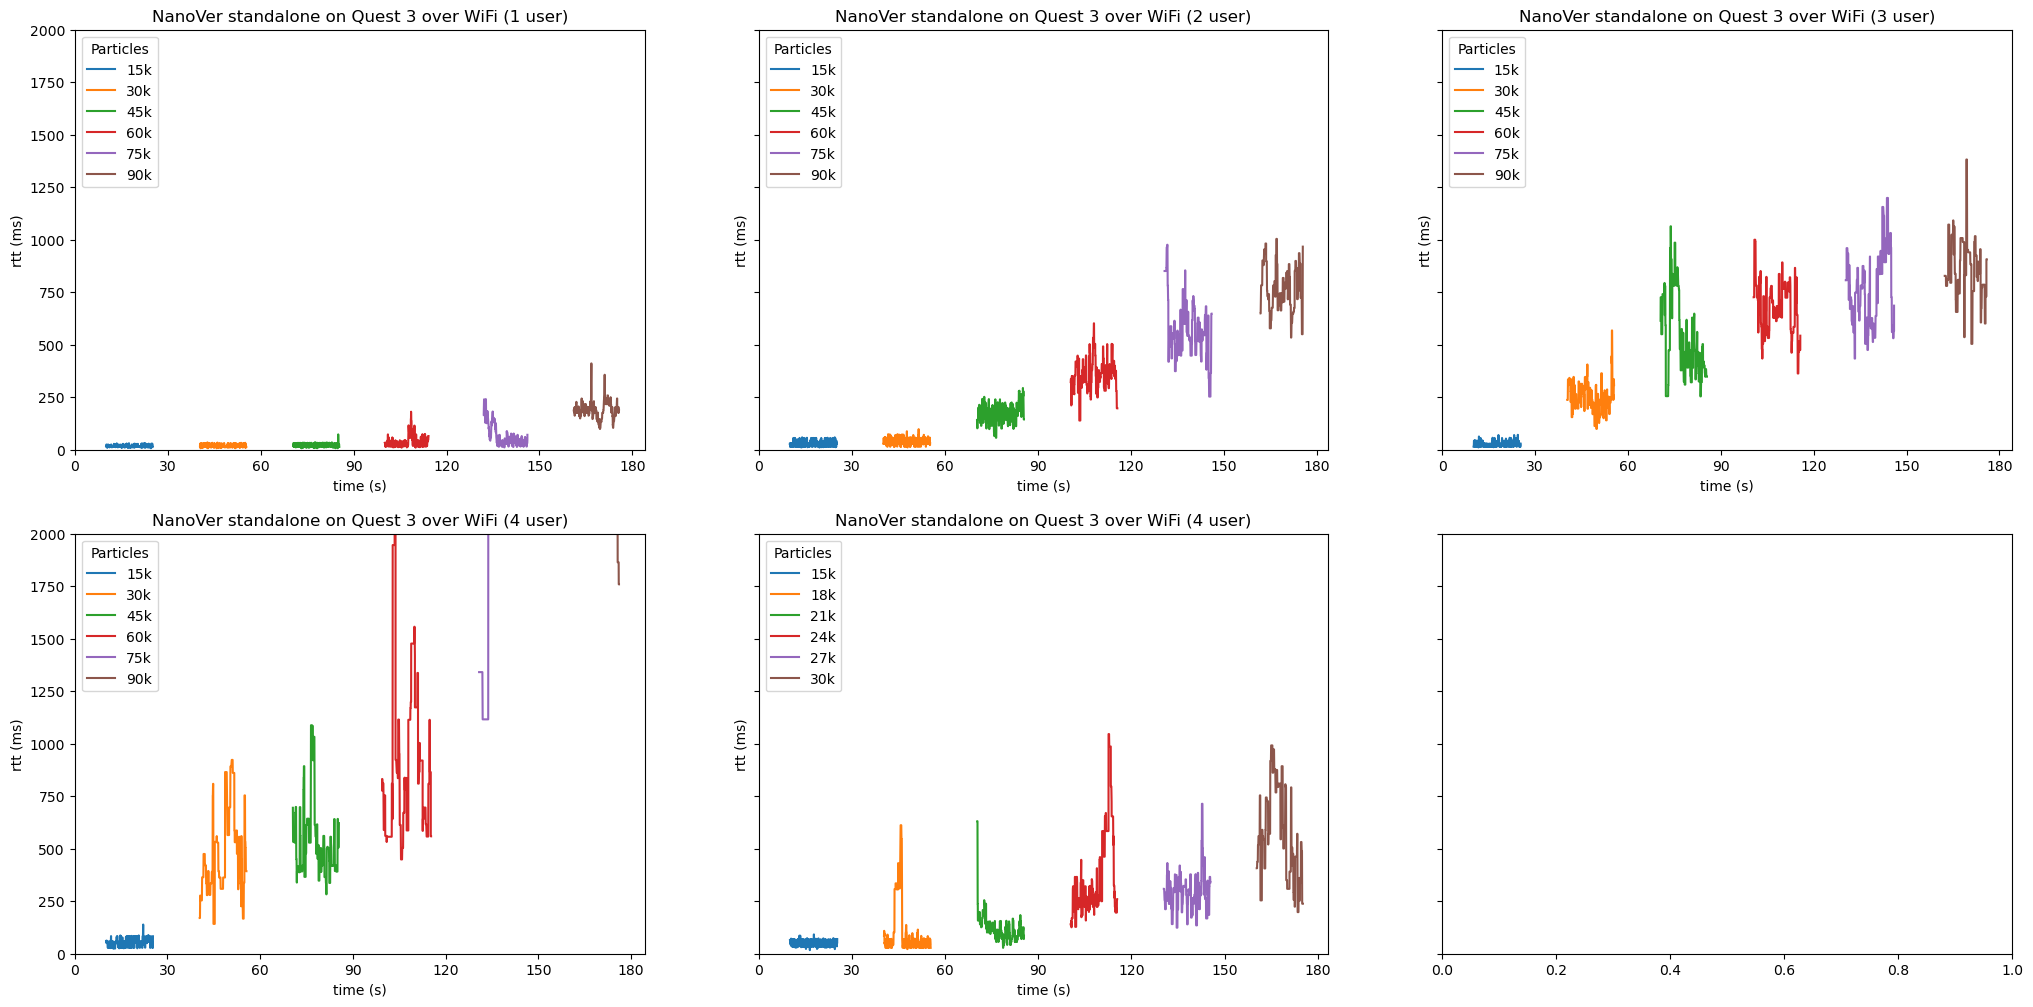

In [46]:
import matplotlib.pyplot as plt
import numpy as np

f, axes = plt.subplots(2, 3, sharey=True)
f.set_figwidth(25)
f.set_figheight(12)

for i, (DATASET, LABEL) in enumerate(DATASETS_REDO):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("rtt (ms)")

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
        third = len(DATA) // 3
        sixth = len(DATA) // 6
        DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        ax.plot(DATA_X, DATA_Y, label=f"{count//1000}k")

    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    # ax.hlines(30, 0, max(DATA_X), color="red", linestyles="dotted")
    ax.set_xticks([x*30 for x in range(len(DATASETS)+2)])
    ax.legend(title="Particles", loc="upper left")

plt.ylim(top=2000, bottom=0)
# plt.ylim(top=250)

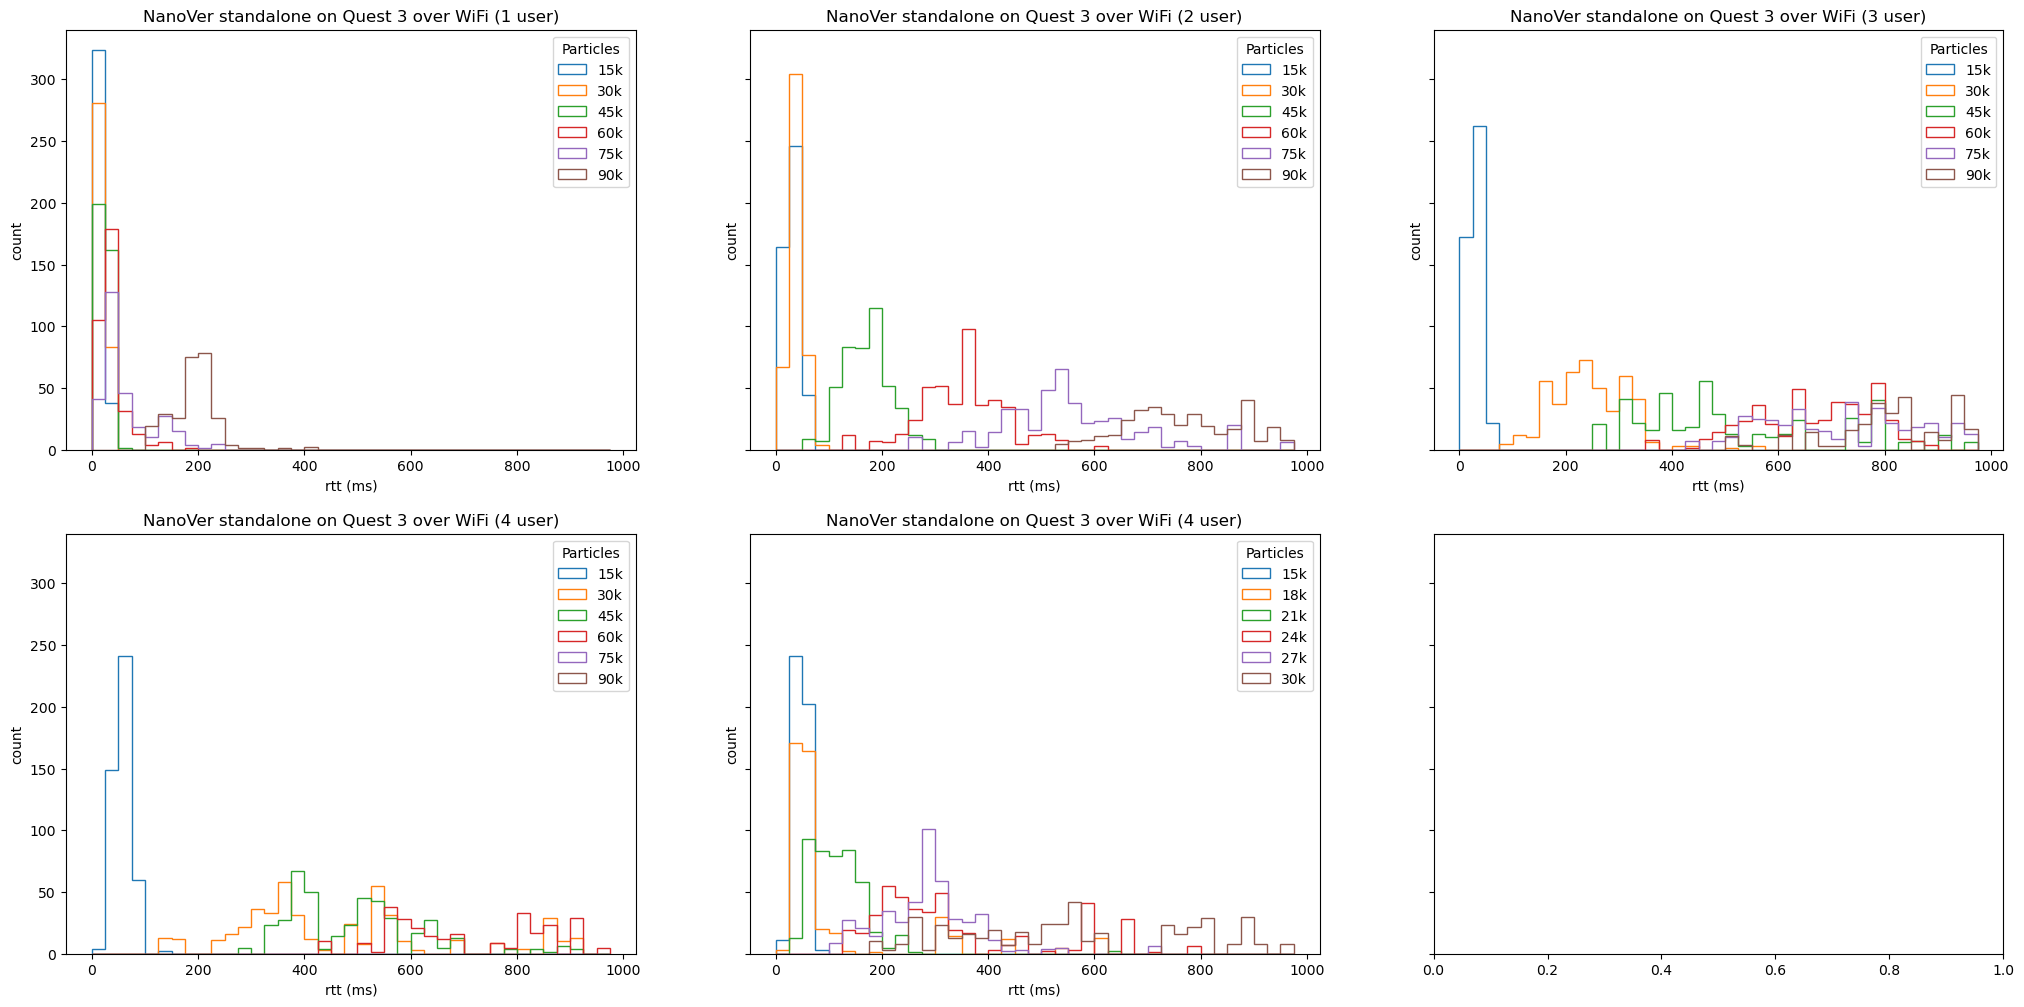

In [8]:
import matplotlib.pyplot as plt
import numpy as np

f, axes = plt.subplots(2, 3, sharey=True)
f.set_figwidth(25)
f.set_figheight(12)

for i, (DATASET, LABEL) in enumerate(DATASETS_REDO):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.set_xlabel("rtt (ms)")
    ax.set_ylabel("count")

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
        third = len(DATA) // 3
        sixth = len(DATA) // 6
        DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        # ax.plot(DATA_X, DATA_Y, label=f"{count//1000}k")

        # counts, bins = np.histogram(DATA_Y)
        ax.hist(DATA_Y, bins=[25*i for i in range(40)], label=f"{count//1000}k", histtype='step')

    ax.legend(title="Particles", loc="upper right")
    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    # # ax.hlines(30, 0, max(DATA_X), color="red", linestyles="dotted")
    # ax.set_xticks([x*30 for x in range(len(DATASETS)+2)])
    # ax.legend(title="Particles", loc="lower left")

# plt.ylim(top=2000, bottom=0)
# plt.ylim(top=250)

(0.0, 500.0)

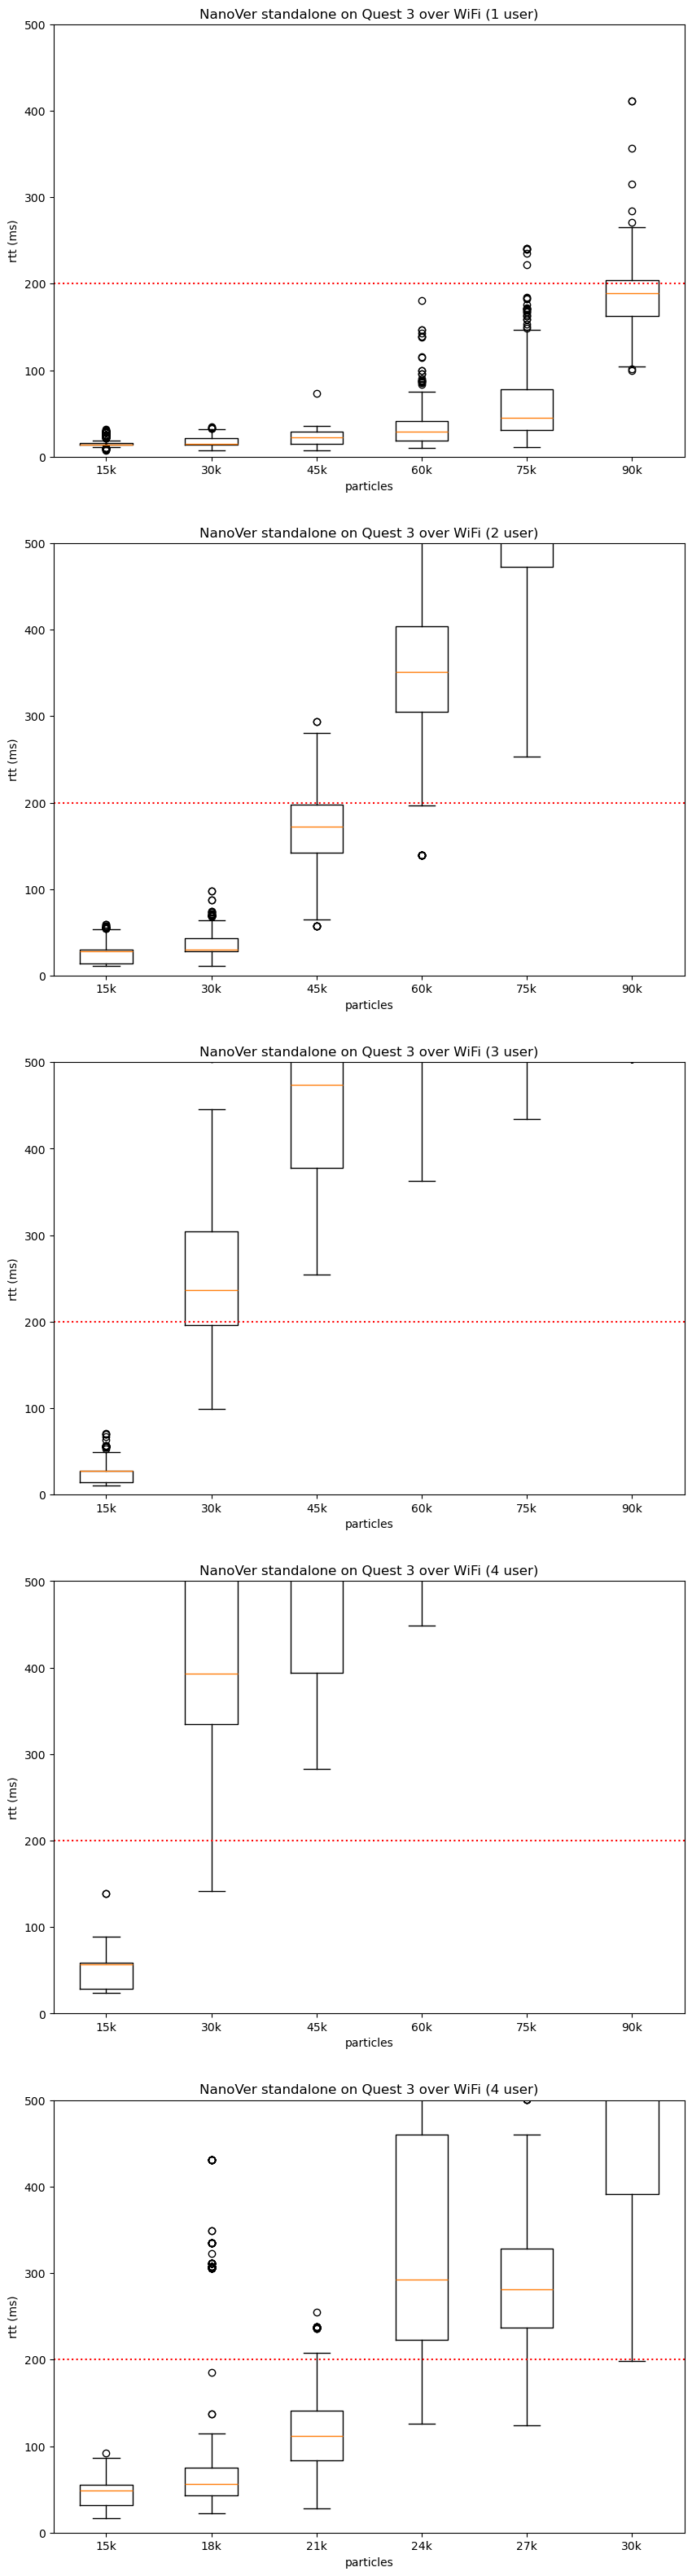

In [82]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(5, 1, sharey=True)
f.set_figwidth(10)
f.set_figheight(40)

for i, (DATASET, LABEL) in enumerate(DATASETS_REDO):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    ax.set_xlabel("particles")
    ax.set_ylabel("rtt (ms)")

    DATAS = []
    LABELS = []

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
        third = len(DATA) // 3
        sixth = len(DATA) // 6
        DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        DATAS.append(DATA_Y)
        LABELS.append(f"{count//1000}k")

    ax.boxplot(DATAS, orientation="vertical", tick_labels=LABELS)
    ax.axhline(200, 0, 1, color="red", linestyle="dotted")

plt.ylim(top=500, bottom=0)

(0.0, 1500.0)

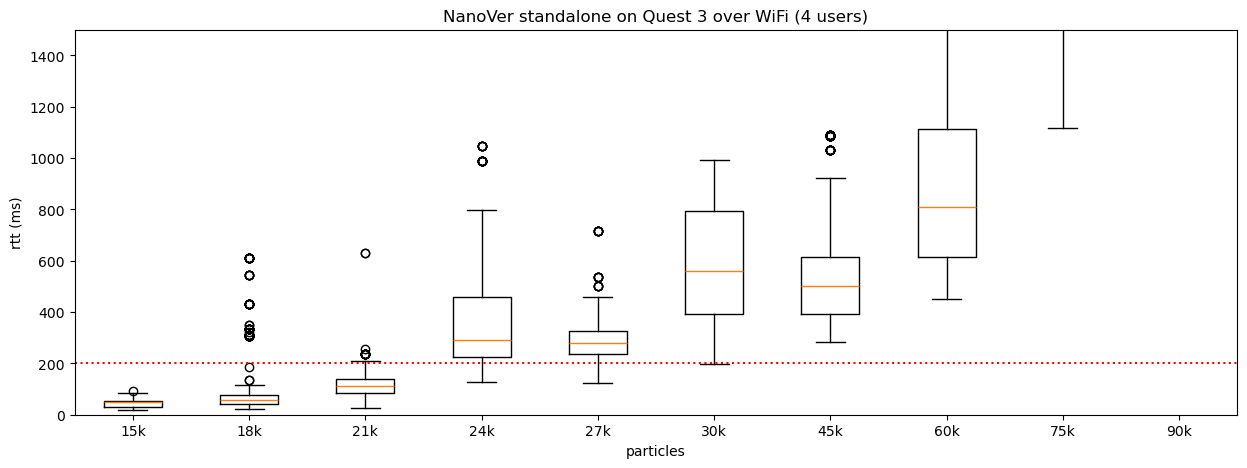

In [75]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(1, sharey=True)
f.set_figwidth(15)
f.set_figheight(5)

ax = axes
ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi (4 users)")
ax.set_xlabel("particles")
ax.set_ylabel("rtt (ms)")

DATAS = []
LABELS = []

DATASET = DATASETS_REDO[4][0]
COUNTS = sorted(set(line["particles"] for line in DATASET))
for count in COUNTS:
    DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
    third = len(DATA) // 3
    sixth = len(DATA) // 6
    DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
    DATAS.append(DATA_Y)
    LABELS.append(f"{count//1000}k")

DATASET = DATASETS_REDO[3][0]
COUNTS = sorted(set(line["particles"] for line in DATASET))[2:]
for count in COUNTS:
    DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
    third = len(DATA) // 3
    sixth = len(DATA) // 6
    DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
    DATAS.append(DATA_Y)
    LABELS.append(f"{count//1000}k")

ax.boxplot(DATAS, orientation="vertical", tick_labels=LABELS)
ax.axhline(200, 0, 1, color="red", linestyle="dotted")

plt.ylim(top=1500, bottom=0)

(0.0, 35.0)

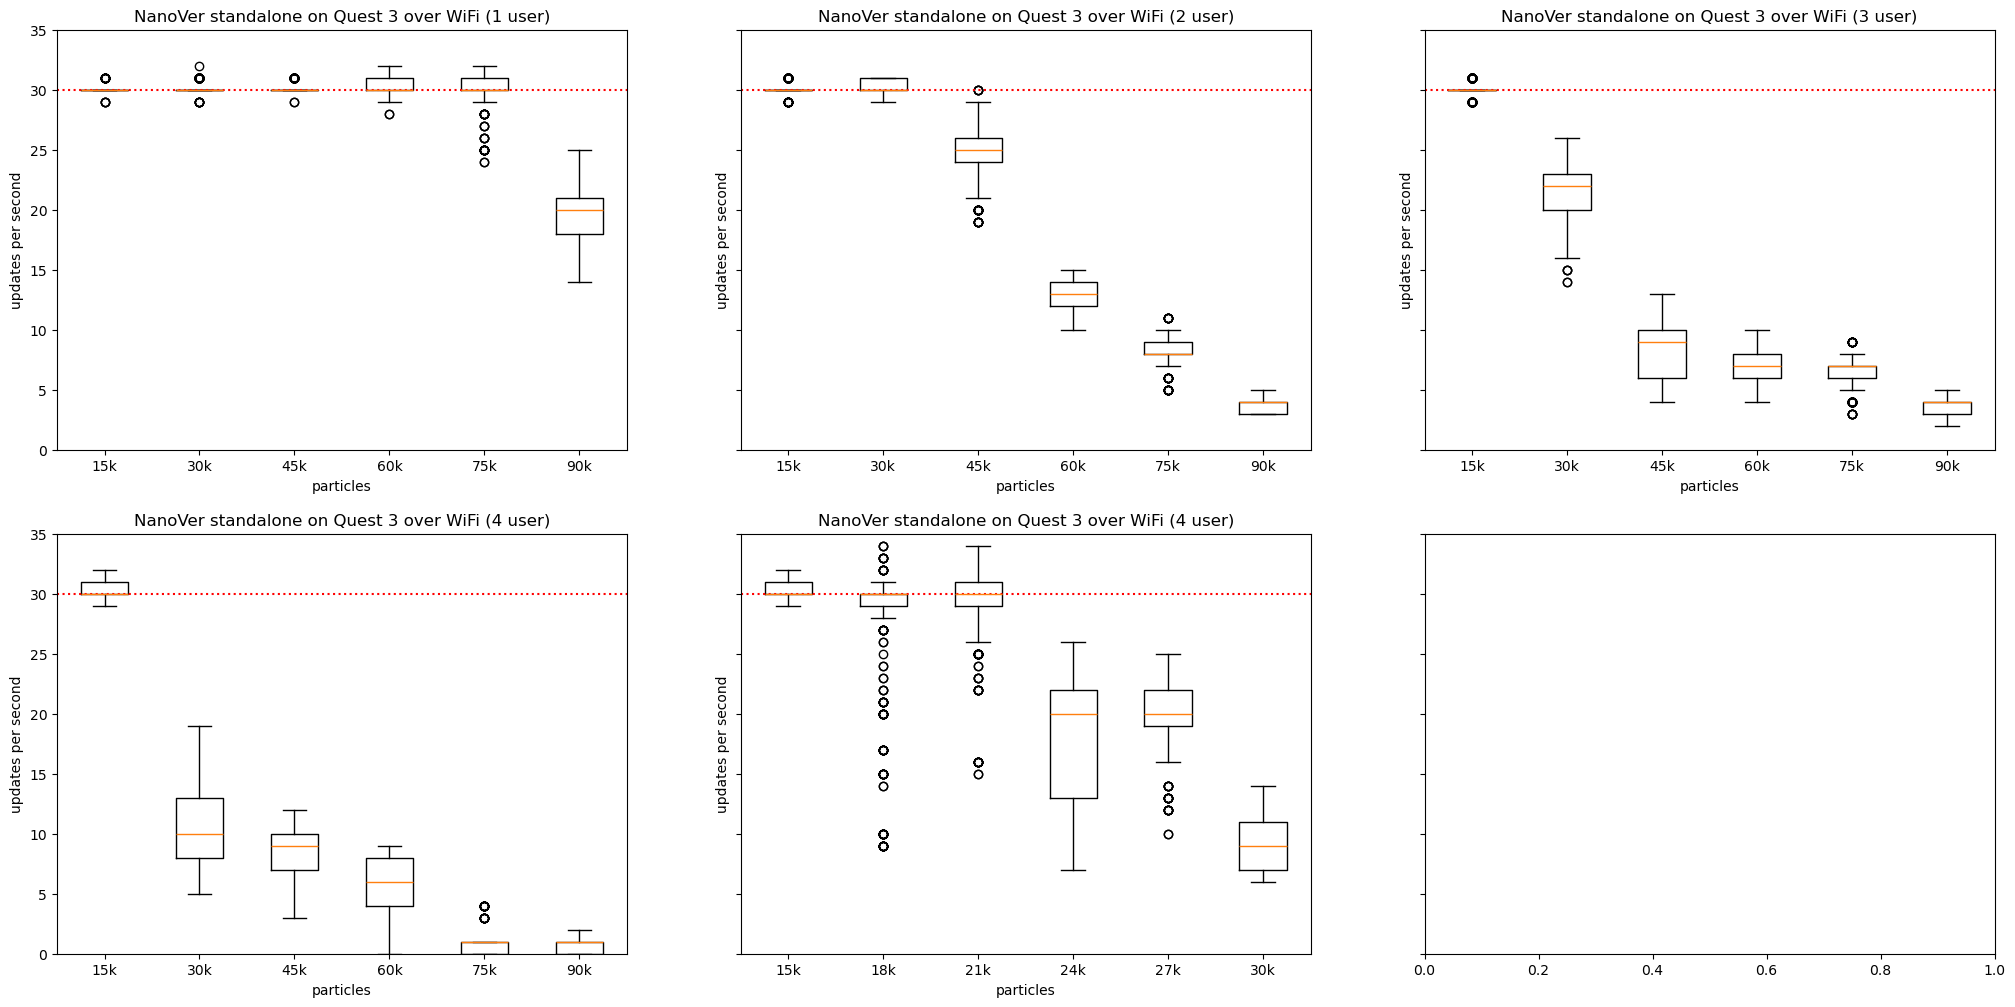

In [74]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(2, 3, sharey=True)
f.set_figwidth(25)
f.set_figheight(12)

for i, (DATASET, LABEL) in enumerate(DATASETS_REDO):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    ax.set_xlabel("particles")
    ax.set_ylabel("updates per second")

    DATAS = []
    LABELS = []

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["frame"]] for line in DATASET if line["particles"] == count]
        third = len(DATA) // 3
        sixth = len(DATA) // 6
        DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        DATAS.append(DATA_Y)
        LABELS.append(f"{count//1000}k")

    ax.boxplot(DATAS, orientation="vertical", tick_labels=LABELS)
    ax.axhline(30, 0, 1, color="red", linestyle="dotted")

plt.ylim(top=35, bottom=0)

(0.0, 75.0)

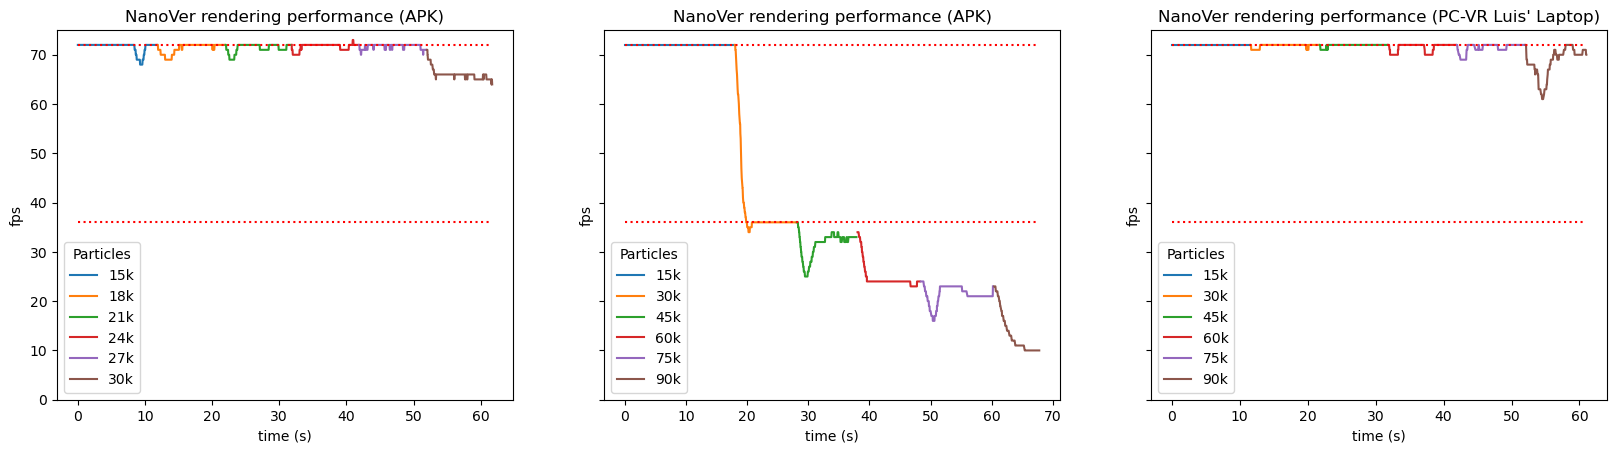

In [4]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(1, 3, sharey=True)
f.set_figwidth(20)

DATASETS = [
    (SOLVENT_VISIBLE_1_USER_APK_FPS_GRANULAR, "APK"),
    (SOLVENT_VISIBLE_1_USER_APK_FPS, "APK"),
    (SOLVENT_VISIBLE_1_USER_PC_FPS_GRANULAR, "PC-VR Luis' Laptop"),
]

for i, (DATASET, LABEL) in enumerate(DATASETS):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("fps")

    for count in COUNTS:
        DATA = [[line["timestamp"]/ 10**6, line["fps"]] for line in DATASET if line["particles"] == count]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [pair[1] for pair in DATA]

        ax.plot(DATA_X, DATA_Y, label=f"{count//1000}k")

    ax.legend(title="Particles", loc="lower left")
    ax.title.set_text(f"NanoVer rendering performance ({LABEL})")
    ax.hlines(72, 0, max(DATA_X), color="red", linestyles="dotted")
    ax.hlines(36, 0, max(DATA_X), color="red", linestyles="dotted")
    # ax.set_xticks([])



plt.ylim(top=75, bottom=0)

7828 x report.connection.health.8eb11c05-b029-4df9-bc9e-723b2cb3e89c
6646 x report.connection.health.03628828-fb96-4241-adc3-c957c49a6e32
7204 x report.connection.health.b0c9dc8e-8a42-4384-a733-0689caab0ce4


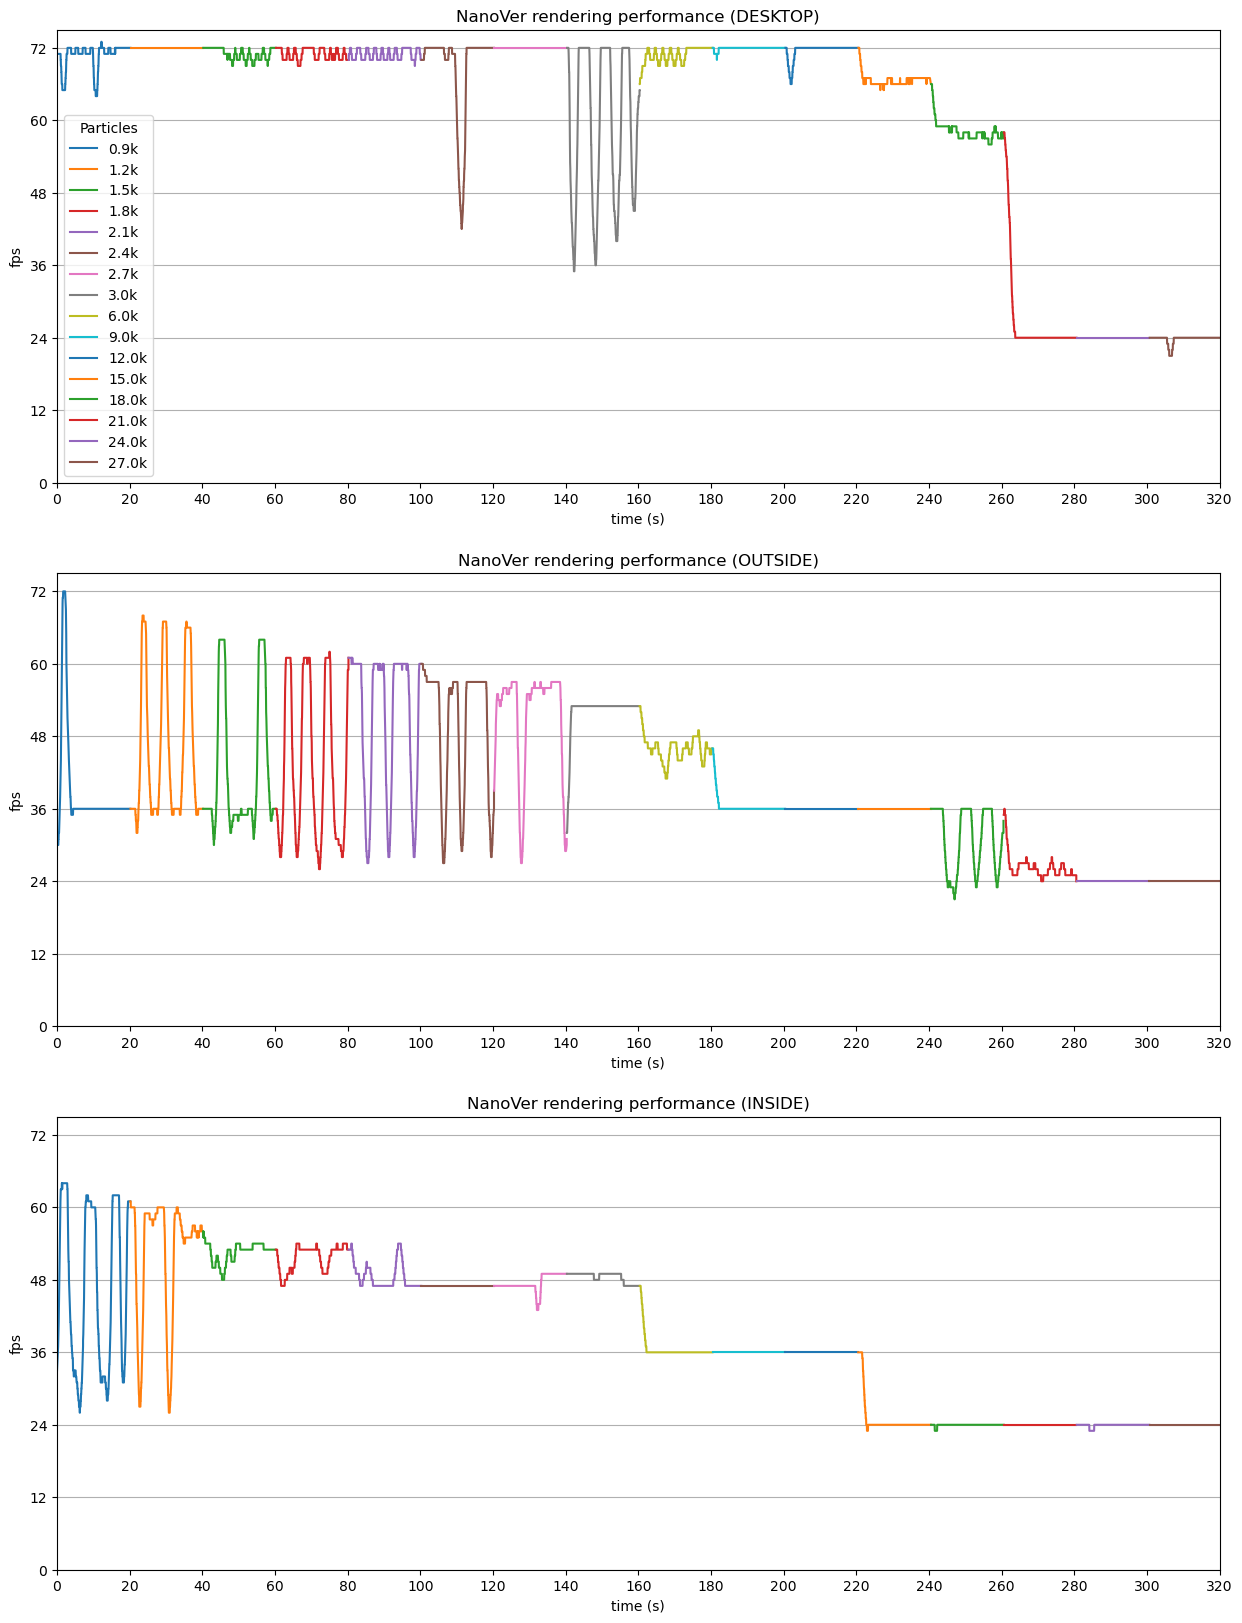

In [20]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(3, 1)
f.set_figwidth(15)
f.set_figheight(20)


SOLVENT_HIDDEN_1_USER_APK_FPS_DESKTOP = read_recording("solvent-visible-1-user--apk--desktop.nanover.zip")
SOLVENT_HIDDEN_1_USER_APK_FPS_OUTSIDE = read_recording("solvent-visible-1-user--apk--outside.nanover.zip")
SOLVENT_HIDDEN_1_USER_APK_FPS_INSIDE = read_recording("solvent-visible-1-user--apk--inside.nanover.zip")

DATASETS = [
    (SOLVENT_HIDDEN_1_USER_APK_FPS_DESKTOP, "DESKTOP"),
    (SOLVENT_HIDDEN_1_USER_APK_FPS_OUTSIDE, "OUTSIDE"),
    (SOLVENT_HIDDEN_1_USER_APK_FPS_INSIDE, "INSIDE"),
]

FPS_TICKS = [72, 60, 48, 36, 24, 12, 0]

for i, (DATASET, LABEL) in enumerate(DATASETS):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("fps")
    ax.grid(axis="y")

    ax.set_xlim(left=0, right=320)
    ax.set_ylim(top=75, bottom=0)

    for count in COUNTS:
        DATA = [[line["timestamp"]/ 10**6, line["fps"]] for line in DATASET if line["particles"] == count]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [pair[1] for pair in DATA]

        ax.plot(DATA_X, DATA_Y, label=f"{count/1000}k")

    if (i == 0):
        ax.legend(title="Particles", loc="lower left")
    ax.title.set_text(f"NanoVer rendering performance ({LABEL})")
    # for fps in FPS_TICKS:
    #     ax.hlines(fps, 0, max(DATA_X), color="red", linestyles="dotted")
    ax.set_xticks([x*20 for x in range(17)])
    ax.set_yticks(FPS_TICKS)


7828 x report.connection.health.8eb11c05-b029-4df9-bc9e-723b2cb3e89c
9165 x report.connection.health.79e6814d-35f3-4148-8d0d-24fb1632ea14
7204 x report.connection.health.b0c9dc8e-8a42-4384-a733-0689caab0ce4


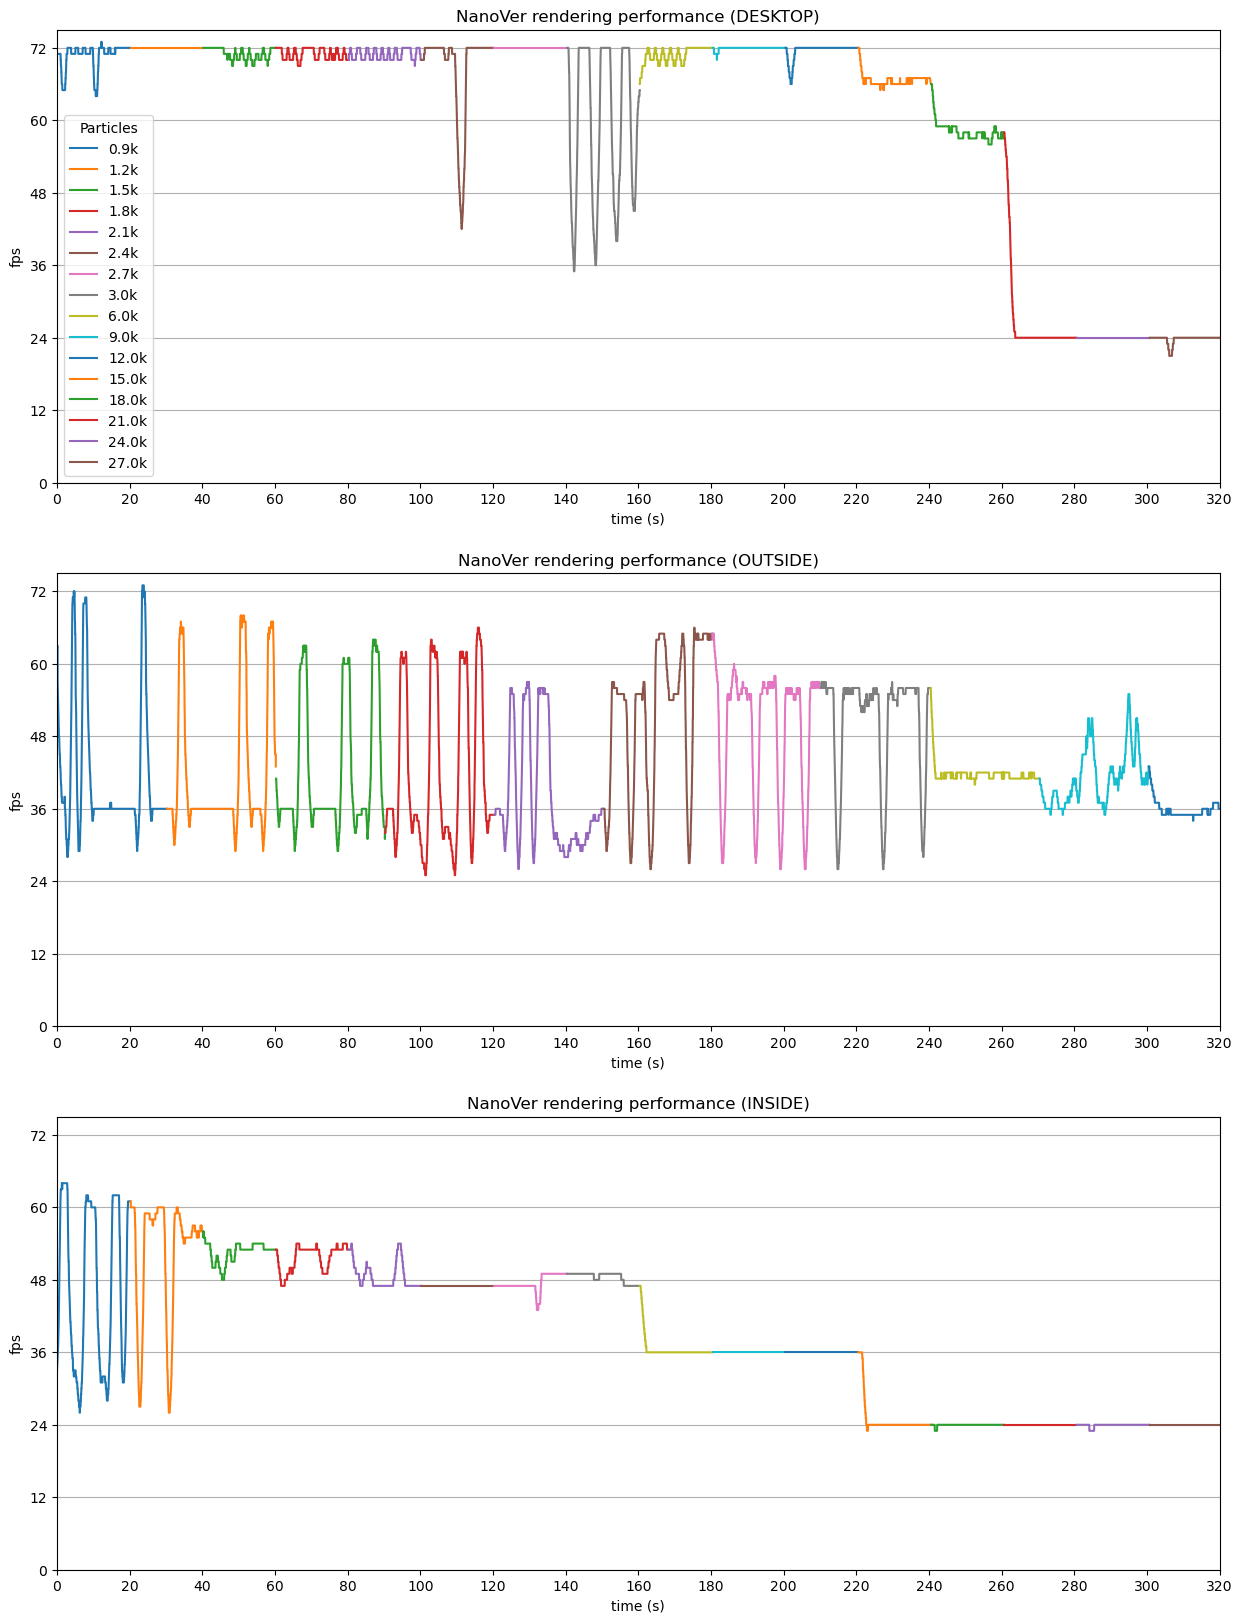

In [83]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(3, 1)
f.set_figwidth(15)
f.set_figheight(20)


SOLVENT_HIDDEN_1_USER_APK_FPS_DESKTOP = read_recording("solvent-visible-1-user--apk--desktop.nanover.zip")
SOLVENT_HIDDEN_1_USER_APK_FPS_OUTSIDE = read_recording("REDO--solvent-visible-1-user--apk--outside.nanover.zip")
SOLVENT_HIDDEN_1_USER_APK_FPS_INSIDE = read_recording("solvent-visible-1-user--apk--inside.nanover.zip")

DATASETS = [
    (SOLVENT_HIDDEN_1_USER_APK_FPS_DESKTOP, "DESKTOP"),
    (SOLVENT_HIDDEN_1_USER_APK_FPS_OUTSIDE, "OUTSIDE"),
    (SOLVENT_HIDDEN_1_USER_APK_FPS_INSIDE, "INSIDE"),
]

FPS_TICKS = [72, 60, 48, 36, 24, 12, 0]

for i, (DATASET, LABEL) in enumerate(DATASETS):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("fps")
    ax.grid(axis="y")

    ax.set_xlim(left=0, right=320)
    ax.set_ylim(top=75, bottom=0)

    for count in COUNTS:
        DATA = [[line["timestamp"]/ 10**6, line["fps"]] for line in DATASET if line["particles"] == count]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [pair[1] for pair in DATA]

        ax.plot(DATA_X, DATA_Y, label=f"{count/1000}k")

    if (i == 0):
        ax.legend(title="Particles", loc="lower left")
    ax.title.set_text(f"NanoVer rendering performance ({LABEL})")
    # for fps in FPS_TICKS:
    #     ax.hlines(fps, 0, max(DATA_X), color="red", linestyles="dotted")
    ax.set_xticks([x*20 for x in range(17)])
    ax.set_yticks(FPS_TICKS)
